# 02_B_rq1_peak_age_analysis

## Research Question 1
**At what age do players reach peak market value, and how does that differ by broad position?**

This notebook:
1. loads A's frozen lifecycle backbone table,
2. defines the peak-age metric,
3. computes player-level peak age,
4. summarizes differences across broad positions,
5. runs statistical comparisons,
6. produces presentation-ready figures,
7. profiles a slow baseline versus an optimized implementation.


In [1]:
import sys
import time
import cProfile
import io
import pstats
from pathlib import Path

# Resolve project root whether running locally or on Colab
_candidates = [
    Path("/Users/fqxin/Desktop/1019_Py/football_lifecycle"),
    Path("/content/drive/MyDrive/football_lifecycle"),
    Path("../"),  # if notebook is inside notebooks/
]
PROJECT_ROOT = next(
    (p.resolve() for p in _candidates if (p / "data" / "processed").exists()), None
)
if PROJECT_ROOT is None:
    raise RuntimeError("Cannot find project root. Add your path to _candidates above.")

sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

INTERIM      = PROJECT_ROOT / "data" / "interim"
PROCESSED    = PROJECT_ROOT / "data" / "processed"
OUT_TABLES   = PROJECT_ROOT / "outputs" / "tables"
OUT_FIGURES  = PROJECT_ROOT / "outputs" / "figures"
OUT_PROFILING = PROJECT_ROOT / "outputs" / "profiling"

for d in [OUT_TABLES, OUT_FIGURES, OUT_PROFILING]:
    d.mkdir(parents=True, exist_ok=True)

Project root: /Users/fqxin/Desktop/1019_Py/football_lifecycle


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations

from src.b_rq1_peak_age_utils import (
    compute_peak_age,
    summarize_peak_age,
    plot_peak_age_boxplot,
    plot_peak_age_mean_ci,
)

plt.rcParams["figure.dpi"] = 130
VALID_POSITIONS = ["Goalkeeper", "Defender", "Midfielder", "Forward"]

## 1) Load frozen cleaned data

Per the handoff requirements, this analysis uses **A's frozen cleaned lifecycle data** and the shared age / position definitions.


In [3]:
df = pd.read_parquet(PROCESSED / "player_lifecycle_backbone.parquet")
df["broad_position"] = df["broad_position"].astype(str)

print(df.shape)
df.head()

(836635, 13)


,player_id,market_value_date,market_value_eur,player_name,date_of_birth,raw_position,raw_sub_position,broad_position,age_days,age_years,n_market_value_obs,market_value_rank_desc,is_peak_value_obs
0,10,2004-10-03,7000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,9613.0,26.318960,23,9,False
1,10,2005-01-06,9000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,9708.0,26.579055,23,7,False
2,10,2005-05-04,12000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,9826.0,26.902122,23,6,False
3,10,2005-09-29,15000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,9974.0,27.307324,23,5,False
4,10,2006-01-08,20000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,10075.0,27.583847,23,3,False


## 2) Metric definition

For each player, **peak age** is defined as the player's age in years at the **earliest observation where market value reaches its maximum**.

Why use the earliest peak if there are ties?
- some players have multiple rows at the same maximum market value,
- taking the earliest peak avoids double counting,
- each player contributes exactly one peak age to the comparison.


In [4]:
peak_df = compute_peak_age(df)
print(peak_df.shape)
peak_df.head()

(58944, 7)


,player_id,player_name,broad_position,peak_age,market_value_eur,market_value_date,n_market_value_obs
0,10,Miroslav Klose (10),Forward,28.095825,30000000.0,2006-07-14,23
1,100001,Carlos Auzqui (100001),Forward,30.595483,3500000.0,2021-10-19,27
2,100011,Éverton Silva (100011),Defender,27.808350,550000.0,2016-05-26,12
3,100012,Liridon Osmanaj (100012),Forward,20.254620,150000.0,2012-04-06,13
4,1000135,Joselu Pérez (1000135),Forward,19.770021,100000.0,2023-12-19,6


## 3) Descriptive summary by broad position

In [5]:
summary = summarize_peak_age(peak_df)
summary.round(3)

,broad_position,mean,median,std,count,min,max
2,Goalkeeper,24.589,24.142,4.469,6243,16.016,40.871
0,Defender,24.453,24.227,3.636,19258,16.025,41.300
3,Midfielder,24.133,23.817,3.694,17485,15.718,40.512
1,Forward,24.115,23.860,3.658,15958,16.003,40.893


## 4) Main figures

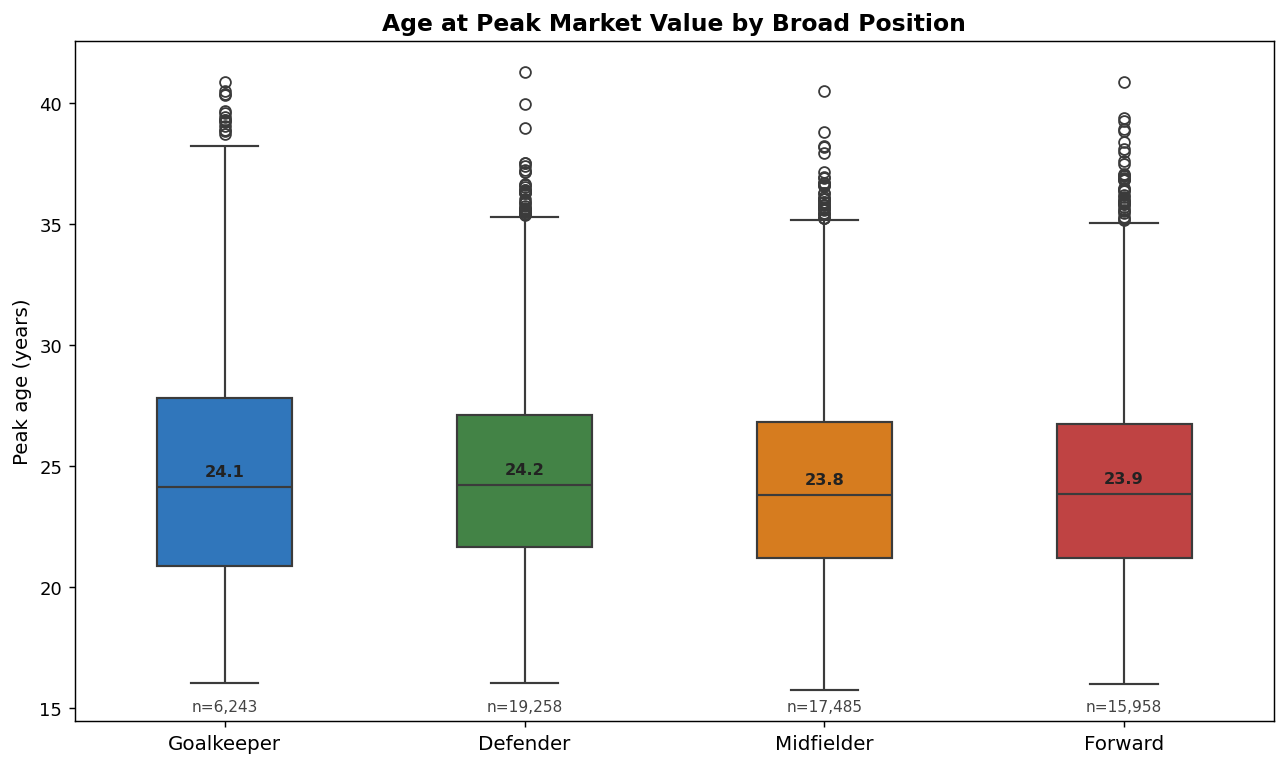

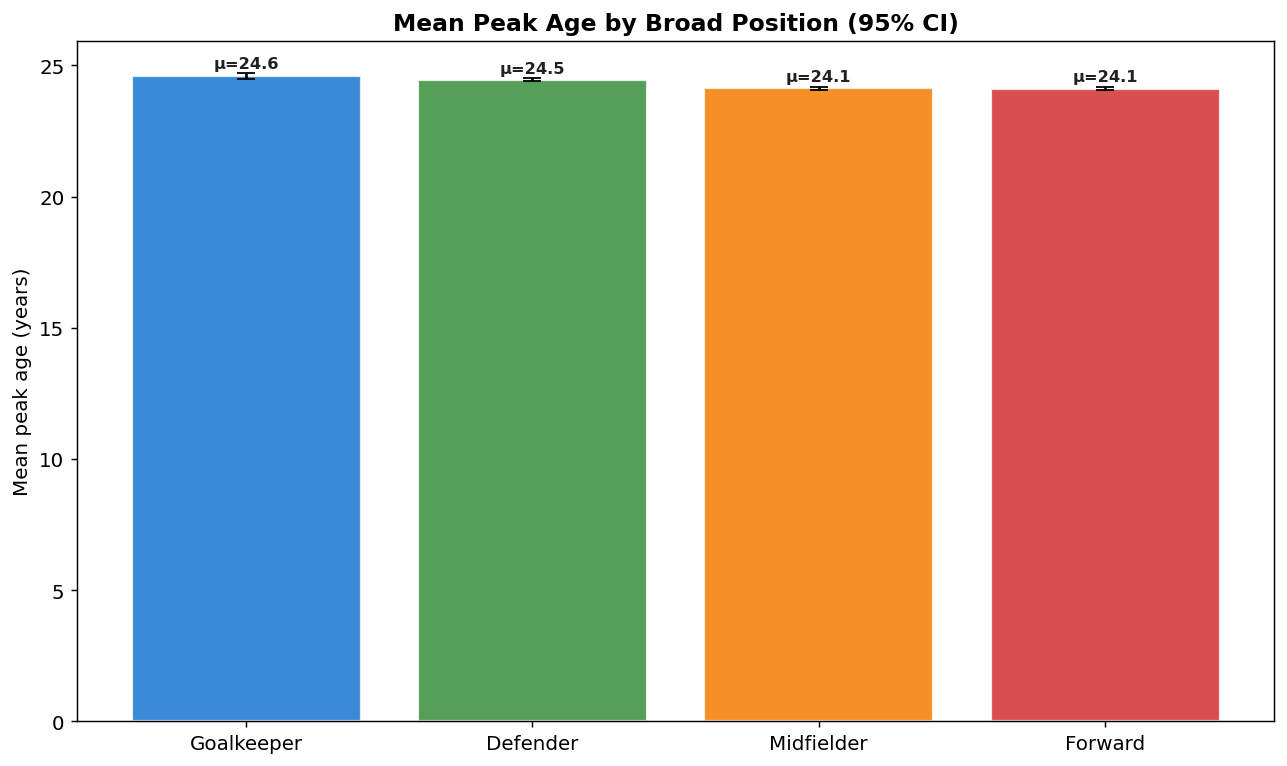

In [6]:
plot_peak_age_boxplot(peak_df, str(OUT_FIGURES / "B_rq1_peak_age_boxplot.png"))
plt.show()

plot_peak_age_mean_ci(peak_df, str(OUT_FIGURES / "B_rq1_peak_age_mean_ci.png"))
plt.show()

## 5) Statistical comparisons

We use:
- **Kruskal–Wallis** for the overall multi-group comparison,
- **Mann–Whitney U** tests with Bonferroni correction for pairwise checks.

These nonparametric tests are appropriate because the group distributions are not perfectly normal and the sample sizes are large.


In [7]:
grouped = {k: g["peak_age"].to_numpy() for k, g in peak_df.groupby("broad_position", observed=True)}
kw = stats.kruskal(*grouped.values())

print(f"Kruskal-Wallis H-statistic = {kw.statistic:.3f}, p-value = {kw.pvalue:.3e}")

kw

Kruskal-Wallis H-statistic = 111.010, p-value = 6.652e-24


KruskalResult(statistic=np.float64(111.01003856309225), pvalue=np.float64(6.6520922727662e-24))

In [8]:
pair_rows = []
for a, b in combinations(sorted(grouped), 2):
    u, p = stats.mannwhitneyu(grouped[a], grouped[b], alternative="two-sided")
    pair_rows.append(
        {"group_1": a, "group_2": b, "p_value": p, "p_value_bonferroni": min(p * 6, 1.0)}
    )
pairwise = pd.DataFrame(pair_rows).sort_values("p_value_bonferroni")
pairwise

,group_1,group_2,p_value,p_value_bonferroni
0,Defender,Forward,1.432932e-18,8.597593e-18
2,Defender,Midfielder,2.733515e-18,1.640109e-17
3,Forward,Goalkeeper,1.807221e-06,1.084333e-05
5,Goalkeeper,Midfielder,3.631949e-06,2.179169e-05
1,Defender,Goalkeeper,4.250521e-01,1.000000e+00
4,Forward,Midfielder,8.204978e-01,1.000000e+00


## 6) Export checkpoint files

In [9]:
summary.round(3).to_csv(OUT_TABLES / "B_rq1_peak_age_summary.csv", index=False)
pairwise.to_csv(OUT_TABLES / "B_rq1_pairwise_tests.csv", index=False)
print("Saved summary and pairwise test CSVs.")

Saved summary and pairwise test CSVs.


## 7) Profiling and optimization

The slow baseline below uses `groupby(...).apply(...)` and recomputes the max value inside each group.

The optimized version:
1. reuses `is_peak_value_obs`,
2. filters to peak rows once,
3. sorts once,
4. keeps the earliest peak row per player with `groupby(...).first()`.

This avoids repeated Python-level work and repeated group scans.


In [10]:
import time

def compute_peak_age_naive(data):
    out = (
        data.sort_values(["player_id", "market_value_date"])
            .groupby("player_id", observed=True)
            .apply(lambda x: x.loc[x["market_value_eur"].eq(x["market_value_eur"].max())].iloc[0])
            .reset_index(drop=True)
    )
    return out

def compute_peak_age_optimized(data):
    peak = (
        data.loc[data["is_peak_value_obs"].fillna(False)]
            .sort_values(["player_id", "market_value_date"])
    )
    out = peak.groupby("player_id", observed=True).first().reset_index()
    return out

baseline_input = df[[
    "player_id", "player_name", "market_value_date", "market_value_eur",
    "broad_position", "age_years", "n_market_value_obs", "is_peak_value_obs"
]].copy()

t0 = time.perf_counter()
naive_out = compute_peak_age_naive(baseline_input)
naive_time = time.perf_counter() - t0

t0 = time.perf_counter()
opt_out = compute_peak_age_optimized(baseline_input)
opt_time = time.perf_counter() - t0

pd.DataFrame({
    "method": ["naive_groupby_apply", "optimized_peak_flag"],
    "runtime_seconds": [naive_time, opt_time],
    "output_rows": [len(naive_out), len(opt_out)]
})

/var/folders/_j/__475r_x6hs0kv9nsh3rt4c40000gn/T/ipykernel_26932/3995375861.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x["market_value_eur"].eq(x["market_value_eur"].max())].iloc[0])


,method,runtime_seconds,output_rows
0,naive_groupby_apply,9.613394,58944
1,optimized_peak_flag,0.059644,58944


In [11]:
# cProfile of the full RQ1 pipeline
profiler = cProfile.Profile()
profiler.enable()
_ = compute_peak_age(df)
profiler.disable()

buf = io.StringIO()
pstats.Stats(profiler, stream=buf).sort_stats("cumtime").print_stats(15)
profile_output = buf.getvalue()

profile_md = f"""# B RQ1 Profiling Note

## Pipeline
Peak age computation over backbone ({len(df):,} rows, {df['player_id'].nunique():,} players).

## Benchmark
| Method | Runtime (s) | Output rows |
|---|---|---|
| naive_groupby_apply | {naive_time:.3f} | {len(naive_out):,} |
| optimized_peak_flag | {opt_time:.3f} | {len(opt_out):,} |

Speedup: **{naive_time / opt_time:.1f}x**

## Optimization strategy
The naive approach scans every player group to find the max market value row.
The optimized version filters on the precomputed `is_peak_value_obs` flag once,
then uses a single sorted groupby.first() — no Python-level per-group iteration.

## cProfile top functions
```
{profile_output[:1500]}
```
"""

profile_path = OUT_PROFILING / "B_rq1_profile.md"
profile_path.write_text(profile_md, encoding="utf-8")
print("Saved:", profile_path)

Saved: /Users/fqxin/Desktop/1019_Py/football_lifecycle/outputs/profiling/B_rq1_profile.md


## 8) Takeaways

- Goalkeepers and defenders peak slightly later than forwards and midfielders.
- The absolute differences are modest, but they are statistically detectable in this large sample.
- Reusing the precomputed peak flag dramatically speeds up the RQ1 pipeline.
